####  Retrieval-Augmented Generation (RAG) 

Document → Chunking → Embeddings → Vector Store → Retrieval → LLM Response

#### Workflow:

1)  Ingestion
2) Retrieval 
3) Response generation

#### 1) Ingestion Pipeline

*   Documents
*   Chunking
*   Embedding generation
*   Vector Storage

1)  Documents:
    *   Raw pdfs, words documents
    *   Company policy data


2) Chunking:
    *   Documents were loaded in list as long string of characters.
    *   Then documents were split and converted into chunks.

        Small chunk size
            Example: 200

        Pros:

            *   More precise retrieval
            *   Better semantic focus
            
        Cons:
        
            *   Context gets fragmented

        Large chunk size

            Example: 1500

            Pros:

            *   More context preserved

            Cons:

            *   Embedding becomes less focused
            *   Retrieval can become noisy

    *   Chunk overlapping import to not loose the context. Overlap means repeat part of previous chunk in next chunk.

        Example:

            Without overlap:

            Chunk 1 → [1.....700]
            Chunk 2 → [701....1400]

            With overlap = 150:

            Chunk 1 → [1........700]
            Chunk 2 → [551.....1250]

            The last 150 characters from chunk 1 are copied into chunk 2.


| Use Case            | Chunk Size | Overlap |
| ------------------- | ---------- | ------- |
| FAQ / short docs    | 300–500    | 50–100  |
| General documents   | 500–1000   | 100–200 |
| Technical documents | 800–1200   | 150–250 |
| Code files          | 200–400    | 50–80   |
| Research papers     | 1000–1500  | 200–300 |


You can explain it like this:

“I used RecursiveCharacterTextSplitter to divide large documents into manageable chunks for embedding and retrieval.
chunk_size=700 means each chunk contains up to 700 characters.
chunk_overlap=150 ensures 150 characters from the previous chunk are repeated in the next chunk so contextual continuity is maintained.
I chose 700 because smaller chunks improve retrieval precision, and 150 overlap (~20%) prevents semantic loss when important information lies near chunk boundaries.”

        

#### 3) Embedding generation:

    *   Each chunks are embedded with sentence tansformers.
    *   A large document is split into smaller pieces (chunks), and each chunk is converted into a semantic vector (embedding) using a pretrained embedding models like all-MiniLM-L6-v2, so the system can later search by meaning instead of exact keywords.

Note:
1) A vector is the mathematical structure (an ordered list of numbers).
An embedding is a learned vector that represents the meaning/properties of some object (like a word, sentence, image, etc.).
2) all-MiniLM-L6-v2 reads a sentence/paragraph and converts its meaning into a 384-number vector so similar meanings can be found later using vector similarity search.

#### 4) Vector storage

    *   Once the doc chunks are converted into embedding it stored into vector store like ChromaDB, FAISS, Pinecone etc..
    *   Vector stores are databases optimized to store embeddings and quickly retrieve semantically similar vectors using similarity search algorithms like cosine similarity or nearest-neighbor search.

RAG Pipeline

User Query:
"How does deep learning use Python?"

↓

Convert query to embedding

↓

Vector Search
(FAISS / Pinecone / Chroma)

↓

Retrieve top 20 chunks

↓

Re-rank top 20

↓

Keep top 5 chunks

↓

Send to LLM

↓

Generate answer

### 2) Retrieval Pipeline

    1) Query Embedding — The user query is converted into an embedding.

Major Retrieval Techniques

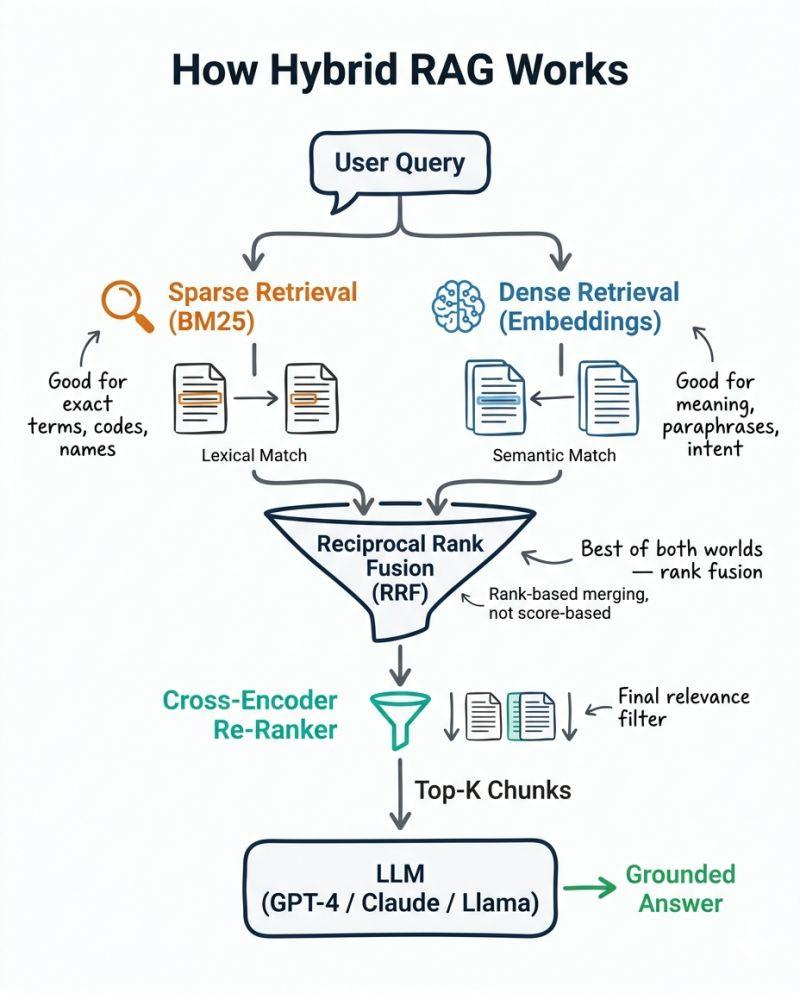

There are 5 common approaches.

1. Keyword Retrieval (Sparse Retrieval) - BM25 -Looks for exact words.
2. Semantic Retrieval (Dense Retrieval) - Uses embeddings. Understands meaning
3. Hybrid Retrieval = Sparse Retrieval +Dense Retrieval
4. Re-ranking = Using re ranking models.
5. Multi-stage Retrieval

    Stage 1 → Fast filtering

    Stage 2 → Semantic search

    Stage 3 → Re-ranking

    Stage 4 → Final top chunks


#### Evaluation.

1. Retrieval Evaluation
2. Generation Evaluation

#### Cosine similarity : Cosine similarity measures the angle between the vectors, not their lengths.

Cosine similarity measures the semantic similarity between two embedding vectors by calculating the cosine of the angle between them. The formula is the dot product of the vectors divided by the product of their magnitudes. A score close to 1 indicates highly similar vectors, while a score close to 0 indicates little similarity. In RAG systems, cosine similarity is commonly used to retrieve the most relevant document chunks for a user's query.

Formula:

    Cosine Similarity= A⋅B/∥A∥×∥B∥
	​


Where:

        * A = First vector (e.g., query embedding)
        * B = Second vector (e.g., document chunk embedding)
        * A · B = Dot product of the vectors
        * ‖A‖ = Magnitude (length) of vector A 
        * ‖B‖ = Magnitude (length) of vector B

For general vectors:

        * +1 → Exactly the same direction (most similar)
        * 0 → No similarity (orthogonal)
        * −1 → Opposite directions

In RAG, embeddings from many modern models are often normalized, so similarity scores are typically between 0 and 1 in practice.

In [1]:
# Dir paths
import os
BASE_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
PARENT_DIR = os.path.dirname(os.path.dirname(BASE_DIR))
RAG_DOC_DIR = os.path.join(PARENT_DIR, "data","RAG","documents")
VECTOR_DB_DIR = os.path.join(PARENT_DIR, "data","RAG","vector_db")
#D:\python\AI\pynb\data\RAG\documents\Nimbus_Tech_Employee_Policies.pdf
COMP_DOC = os.path.join(RAG_DOC_DIR, 'Nimbus_Tech_Employee_Policies.pdf')

In [2]:
# Loading document
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader(file_path=COMP_DOC)

documents = loader.load()

documents[0].metadata

d:\python\AI\pynb\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
d:\python\AI\pynb\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


{'producer': 'ReportLab PDF Library - (opensource)',
 'creator': '(unspecified)',
 'creationdate': '2026-07-05T18:07:09+00:00',
 'author': 'Nimbus Tech Solutions (Fictional)',
 'keywords': '',
 'moddate': '2026-07-05T18:07:09+00:00',
 'subject': '(unspecified)',
 'title': 'Employee Policy Handbook (Sample Data)',
 'trapped': '/False',
 'source': 'd:\\python\\AI\\pynb\\data\\RAG\\documents\\Nimbus_Tech_Employee_Policies.pdf',
 'total_pages': 3,
 'page': 0,
 'page_label': '1'}

In [3]:
# Chunk the document
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=150
)

chunks = splitter.split_documents(documents=documents)

In [4]:
# Overlaped chuks - helps in the retrival with better cotext
print(chunks[0].page_content)
print()
print(chunks[1].page_content)
print()
print(chunks[2].page_content)

Nimbus Tech Solutions
 Employee Policy Handbook
 ■ Synthetic sample document — fictional company, for demonstration/testing purposes only.
1. Code of Conduct
All employees of Nimbus Tech Solutions are expected to act with integrity, honesty, and professionalism in
every interaction, whether with colleagues, clients, vendors, or members of the public. This Code of Conduct
applies to all full-time, part-time, and contract staff across all offices and remote work arrangements.

applies to all full-time, part-time, and contract staff across all offices and remote work arrangements.
1.1 Professional Behavior
 Treat all colleagues, clients, and partners with respect, regardless of role, background, or seniority.
 Communicate honestly and transparently in all business dealings.
 Avoid conflicts of interest; disclose any potential conflict to your manager or HR immediately.
 Refrain from any form of harassment, discrimination, or bullying in the workplace.

 Refrain from any form of haras

In [5]:
# Creating embedding
import os
from dotenv import load_dotenv
load_dotenv()

##llm
from langchain_groq import ChatGroq
os.environ["HF_TOKEN"]=os.getenv("HF_TOKEN")
from langchain_huggingface import HuggingFaceEmbeddings

EMBED_MODEL = 'all-MiniLM-L6-v2'



embedding = HuggingFaceEmbeddings(
    model_name=f"sentence-transformers/{EMBED_MODEL}",
     model_kwargs={
        "device": "cuda"
        }
    )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [6]:
import torch
print(torch.cuda.is_available())

True


In [7]:
#vector_db

from langchain_community.vectorstores import FAISS

# vector_db = FAISS.from_documents(
#     documents=chunks,
#     embedding=embedding
# )

In [8]:
#vector_db.save_local(VECTOR_DB_DIR)

1. index.faiss

        This is the actual FAISS index.

        It contains:

        * Embedding vectors
        * FAISS search structure
        * Vector IDs
        * Index metadata (Flat, IVF, HNSW, etc.)

2. index.pkl

        This is a Python pickle file.

        It stores everything FAISS doesn't.

        Specifically:

        * Original document text
        * Metadata
        * Mapping from vector ID → document


                index.faiss

Vector ID      Embedding

0        [0.23,0.55...]

1        [0.71,-0.19...]

2        [-0.42,0.91...]

        │
        │
        ▼

                index.pkl

0  → "Employees receive 20 leave days"

1  → "Medical insurance..."

2  → "Performance review..."

In [9]:
import faiss


FAISS_INDEX = os.path.join(VECTOR_DB_DIR, 'index.faiss')
PKL_INDEX = os.path.join(VECTOR_DB_DIR, 'index.pkl')


index = faiss.read_index(FAISS_INDEX)
index.ntotal

15

In [10]:
import pickle

with open(PKL_INDEX, "rb") as f:
    data = pickle.load(f)


In [11]:
import numpy as numpy
vector = index.reconstruct(0)

print(type(vector))
print(vector.shape)
print(vector[:20])

<class 'numpy.ndarray'>
(384,)
[-0.08617659  0.04560124  0.02303218 -0.07721484 -0.00796594 -0.02686562
  0.05720559 -0.04343648 -0.04340568  0.00343382 -0.00863823  0.03809801
 -0.02012655  0.02341749  0.02381917 -0.07671829  0.03436404 -0.05180339
  0.0321495  -0.05440576]


In [12]:
docstore = data[0]
index_to_docstore_id = data[1]

print(type(docstore))
print(index_to_docstore_id)

<class 'langchain_community.docstore.in_memory.InMemoryDocstore'>
{0: 'b7b6a7df-ec31-4159-9581-6fcad5481144', 1: '42a1450d-dddd-4fcb-942b-9aa83c58d5c2', 2: 'bbbebd2b-bbfa-4e14-a33e-db14925248bc', 3: '88df7d63-21ab-4e28-8512-02f15068cfd7', 4: 'd2bfb8b7-0b92-4cc2-84f4-1861ce7417bb', 5: 'c3d1241e-9556-43d2-9504-75d17c08bf04', 6: '577fe88e-8fe4-4994-8e24-8e1b67c47534', 7: 'ee3f4e08-b4ed-44d0-a060-4f1ac9a2033b', 8: '29065f72-514b-4577-a585-2d0407b97aeb', 9: 'd093e5c7-5249-4908-b7c8-08ab20a74c92', 10: '12b5687c-bc2a-484e-a24c-d375b48cb171', 11: '2b86194b-3b0c-4d71-bd03-3eabfd64116a', 12: 'cc87a9e2-a69e-4e9c-8d50-36bfa5defd5d', 13: '507a93db-d82c-40e6-985f-0be7a5a9fca8', 14: '6e059279-5155-4a39-bbae-72be8b0bdb0e'}


In [13]:
doc = docstore._dict[index_to_docstore_id[0]]
print(doc)

page_content='Nimbus Tech Solutions
 Employee Policy Handbook
 ■ Synthetic sample document — fictional company, for demonstration/testing purposes only.
1. Code of Conduct
All employees of Nimbus Tech Solutions are expected to act with integrity, honesty, and professionalism in
every interaction, whether with colleagues, clients, vendors, or members of the public. This Code of Conduct
applies to all full-time, part-time, and contract staff across all offices and remote work arrangements.' metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-05T18:07:09+00:00', 'author': 'Nimbus Tech Solutions (Fictional)', 'keywords': '', 'moddate': '2026-07-05T18:07:09+00:00', 'subject': '(unspecified)', 'title': 'Employee Policy Handbook (Sample Data)', 'trapped': '/False', 'source': 'd:\\python\\AI\\pynb\\data\\RAG\\documents\\Nimbus_Tech_Employee_Policies.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}


#### Retrieval

In [14]:
vector_db_retrieve = FAISS.load_local(
    VECTOR_DB_DIR,
    embedding,
    allow_dangerous_deserialization=True
)

In [15]:
query = "Give info on sick leaves"

results = vector_db_retrieve.similarity_search(
    query=query,
    k=3
)

In [16]:
for i, doc in enumerate(results, start=1):
    print(f"\n---------- Chunk {i} ----------")
    print(doc.page_content)
    print(doc.metadata)


---------- Chunk 1 ----------
20 days
Accrued monthly; max carryover of 5 days
Sick Leave
10 days
Medical certificate required after 3 consecutive days
Parental Leave
16 weeks
Available to all primary caregivers
Bereavement Leave
5 days
Immediate family; 2 days for extended family
Public Holidays
12 days
As per regional holiday calendar
4. Information Technology and Security Policy
All employees are responsible for safeguarding company systems, devices, and data. Adherence to this
{'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-05T18:07:09+00:00', 'author': 'Nimbus Tech Solutions (Fictional)', 'keywords': '', 'moddate': '2026-07-05T18:07:09+00:00', 'subject': '(unspecified)', 'title': 'Employee Policy Handbook (Sample Data)', 'trapped': '/False', 'source': 'd:\\python\\AI\\pynb\\data\\RAG\\documents\\Nimbus_Tech_Employee_Policies.pdf', 'total_pages': 3, 'page': 1, 'page_label': '2'}

---------- Chunk 2 ----------
3. Leave and T

In [17]:
## Langchain retriever

retriever = vector_db_retrieve.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 3
    }
)

In [18]:
documents = retriever.invoke(query)

for doc in documents:
    print(doc.page_content)

20 days
Accrued monthly; max carryover of 5 days
Sick Leave
10 days
Medical certificate required after 3 consecutive days
Parental Leave
16 weeks
Available to all primary caregivers
Bereavement Leave
5 days
Immediate family; 2 days for extended family
Public Holidays
12 days
As per regional holiday calendar
4. Information Technology and Security Policy
All employees are responsible for safeguarding company systems, devices, and data. Adherence to this
3. Leave and Time-Off Policy
Nimbus Tech Solutions provides a range of paid and unpaid leave options to support employee wellbeing.
Leave requests should be submitted through the HR portal at least five business days in advance where
possible, except in cases of emergency or illness.
Leave Type
Annual Entitlement
Notes
Paid Time Off (PTO)
20 days
Accrued monthly; max carryover of 5 days
Sick Leave
10 days
Medical certificate required after 3 consecutive days
Parental Leave
16 weeks
5. Workplace Health and Safety
Nimbus Tech Solutions is c

#### Hybrid Search

Documents
        │
        ├──────────────┐
        ▼              ▼
   Dense Index     Sparse Index
    (FAISS)      (BM25/Elasticsearch/OpenSearch)
        │              │
        └──────┬───────┘
               ▼
        Hybrid Retriever

* Dense retriver - fetches relevent embedding using cosine similarity
* bm25 retriver - fetches relevent documents using keywords

BM25 builds an inverted index.

Example documents:

Doc 1:

    Employees receive annual leave.

Doc 2:

    Medical insurance is provided.

BM25 internally creates something like:

        employees  → Doc1
        receive    → Doc1
        annual     → Doc1
        leave       → Doc1

        medical    → Doc2
        insurance  → Doc2
        provided   → Doc2

In [19]:
dense_retriever = vector_db_retrieve.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 3
    }
)

In [20]:
#### BM25 Retriever
from langchain_community.retrievers import BM25Retriever

documents = list(vector_db_retrieve.docstore._dict.values())

bm25_retriever = BM25Retriever.from_documents(documents)

bm25_retriever.k = 5


In [21]:
from langchain_classic.retrievers import EnsembleRetriever


hybrid = EnsembleRetriever(
    retrievers=[
        bm25_retriever,
        dense_retriever
    ],
    weights=[
        0.4,
        0.6
    ]
)

In [22]:
query = "What the working time?"

docs = hybrid.invoke(query)
len(docs)

6

In [23]:
for doc in docs:
    print("="*80)
    print(doc.page_content)

2. Attendance and Working Hours
Standard working hours at Nimbus Tech Solutions are Monday through Friday, 9:00 AM to 5:30 PM, with a
one-hour lunch break. Flexible scheduling and hybrid work arrangements are available subject to manager
approval and team requirements.
Category
Details
Core Hours
10:00 AM – 4:00 PM (all staff expected to be available)
Remote Work
Up to 3 days/week, subject to manager approval
Late Arrival
Notify manager within 30 minutes of scheduled start time
Overtime
individuals during or after employment with Nimbus Tech Solutions.
1.3 Conflicts of Interest
Employees must avoid situations where personal interests could conflict with the interests of Nimbus Tech
Solutions. This includes outside employment, financial investments in competitors, and close personal
relationships that could impact business decisions.
2. Attendance and Working Hours
Standard working hours at Nimbus Tech Solutions are Monday through Friday, 9:00 AM to 5:30 PM, with a
Remote Work
Up to 3 d

#### If you're using ChromaDB, how would you perform BM25?

"ChromaDB is a vector database optimized for dense retrieval and doesn't execute BM25 over embeddings. I would build a separate BM25 index from the same original documents. During retrieval, I'd query both the dense retriever (ChromaDB) and the sparse retriever (BM25 or Elasticsearch/OpenSearch), then merge the ranked results using a technique like Reciprocal Rank Fusion before optionally reranking them."

#### Reranking

                User Query
                     │
         ┌───────────┴───────────┐
         ▼                       ▼
     Dense Search           Sparse Search
       (FAISS)                (BM25)
         │                       │
         └───────────┬───────────┘
                     ▼
             Hybrid Retrieval
                     │
              Top 20 Documents
                     ▼
               Cross Encoder
                (Reranker)
                     ▼
              Top 5 Documents
                     ▼
                   LLM

#### Why reranking?

Query: What is the leave policy?

| Rank | Document                |
| ---- | ----------------------- |
| 1    | Annual leave policy     |
| 2    | Medical leave policy    |
| 3    | Leave approval workflow |
| 4    | Holiday calendar        |
| 5    | Remote work policy      |

These are all relevant, but not equally relevant.

<b>The LLM has a limited context window.</b>

Instead of giving it all 20 documents, we want to provide only the best 3–5.

That's the job of the reranker.

In [24]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2" # this model is specifically trained for reranking.
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

#### Cross encoder

* A cross encoder takes the query and one document together.
* The transformer processes both together.

Eg:
    Query:

        What is the leave policy?

    Document:

        Employees receive 20 annual leave days.

    Relevance Score = 0.98

    Query:

        What is the leave policy?

    Document:

        Medical insurance covers dependents.

    Relevance Score = 0.98
    

In [25]:
query = "What the working time?"

docs = hybrid.invoke(query)
len(docs)

6

In [26]:
## A cross encoder expects pairs.

pairs = [
    (query, doc.page_content)
    for doc in docs
]

pairs

[('What the working time?',
  '2. Attendance and Working Hours\nStandard working hours at Nimbus Tech Solutions are Monday through Friday, 9:00 AM to 5:30 PM, with a\none-hour lunch break. Flexible scheduling and hybrid work arrangements are available subject to manager\napproval and team requirements.\nCategory\nDetails\nCore Hours\n10:00 AM – 4:00 PM (all staff expected to be available)\nRemote Work\nUp to 3 days/week, subject to manager approval\nLate Arrival\nNotify manager within 30 minutes of scheduled start time\nOvertime'),
 ('What the working time?',
  'individuals during or after employment with Nimbus Tech Solutions.\n1.3 Conflicts of Interest\nEmployees must avoid situations where personal interests could conflict with the interests of Nimbus Tech\nSolutions. This includes outside employment, financial investments in competitors, and close personal\nrelationships that could impact business decisions.\n2. Attendance and Working Hours\nStandard working hours at Nimbus Tech So

In [27]:
scores = reranker.predict(pairs)

scores

array([ -1.0961597,  -3.8328109,  -1.8159416, -10.555198 , -10.583607 ,
       -10.922066 ], dtype=float32)

In [28]:
reranked = list(zip(scores, docs))

In [29]:
reranked.sort(
    key=lambda x: x[0],
    reverse=True
)

In [30]:
# 6 docs were reranked and top 3 will be given to LLM

top_docs = [
    doc
    for score, doc in reranked[:3]
]

In [31]:
type(top_docs[0])

langchain_core.documents.base.Document

In [32]:
#### Let's create a function that retreving and reranking to use it with LLM

from langchain_core.documents.base import Document

def retrieve_and_rerank(query:str) -> list[Document]:
    docs = hybrid.invoke(query)
    pairs = [(query, doc.page_content) for doc in docs]
    scores = reranker.predict(pairs)
    reranked = list(zip(scores, docs))
    reranked.sort(
            key=lambda x: x[0],
            reverse=True
            )
    top_docs = [doc for score, doc in reranked[:3]]
    return top_docs

In [33]:
query = "What the working time?"
top_docs = retrieve_and_rerank(query=query)
top_docs

[Document(id='d2bfb8b7-0b92-4cc2-84f4-1861ce7417bb', metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-05T18:07:09+00:00', 'author': 'Nimbus Tech Solutions (Fictional)', 'keywords': '', 'moddate': '2026-07-05T18:07:09+00:00', 'subject': '(unspecified)', 'title': 'Employee Policy Handbook (Sample Data)', 'trapped': '/False', 'source': 'd:\\python\\AI\\pynb\\data\\RAG\\documents\\Nimbus_Tech_Employee_Policies.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='2. Attendance and Working Hours\nStandard working hours at Nimbus Tech Solutions are Monday through Friday, 9:00 AM to 5:30 PM, with a\none-hour lunch break. Flexible scheduling and hybrid work arrangements are available subject to manager\napproval and team requirements.\nCategory\nDetails\nCore Hours\n10:00 AM – 4:00 PM (all staff expected to be available)\nRemote Work\nUp to 3 days/week, subject to manager approval\nLate Arrival\nNotify manager wit

In [34]:
import os
from dotenv import load_dotenv
load_dotenv()

##llm
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-120b")

In [35]:
context = "\n".join([d.page_content for d in top_docs])
print(context)

2. Attendance and Working Hours
Standard working hours at Nimbus Tech Solutions are Monday through Friday, 9:00 AM to 5:30 PM, with a
one-hour lunch break. Flexible scheduling and hybrid work arrangements are available subject to manager
approval and team requirements.
Category
Details
Core Hours
10:00 AM – 4:00 PM (all staff expected to be available)
Remote Work
Up to 3 days/week, subject to manager approval
Late Arrival
Notify manager within 30 minutes of scheduled start time
Overtime
Remote Work
Up to 3 days/week, subject to manager approval
Late Arrival
Notify manager within 30 minutes of scheduled start time
Overtime
Pre-approved overtime compensated per local labor law
individuals during or after employment with Nimbus Tech Solutions.
1.3 Conflicts of Interest
Employees must avoid situations where personal interests could conflict with the interests of Nimbus Tech
Solutions. This includes outside employment, financial investments in competitors, and close personal
relationships t

In [36]:
def chat(query:str) -> str:
    top_docs = retrieve_and_rerank(query=query)
    context = "\n".join([d.page_content for d in top_docs])
    prompt = f"""
    Answer using only the context below.

    Context:
    {context}

    Question: {query}
    """
    #print(context)
    resp = llm.invoke(prompt)
    return resp



In [37]:
query = "What should I do if I lost my company provided device?"
resp = chat(query=query)
resp.pretty_print()
resp.content

================================== Ai Message ==================================

You should report the lost device to the IT Security team within 1 hour of discovering it.


'You should report the lost device to the IT\u202fSecurity team within\u202f1\u202fhour of discovering it.'

In [38]:
query = "How may days of leaves will be given for bereavement leave?"
resp = chat(query=query)
resp.pretty_print()

================================== Ai Message ==================================

Bereavement Leave provides **5 days** for the death of an immediate family member and **2 days** for the death of an extended family member.


#### Evaluation

Final part of the RAG system is evaluation, to check which the syatems awnser is accurate.

Two stages of evaluation:

        1) Retrieval Evaluation -  Evaluation of retrieved raw docs from the vector DB
        2) Generation Evaluation - Evaluation of answer generated by the LLM.


                User Query
                     │
                     ▼
                Retriever
                     │
            Retrieved Documents
                     │
            Retrieval Evaluation
                     │
                     ▼
                    LLM
                     │
                    Answer
                     │
            Generation Evaluation

Notice:

* A retriever can be excellent, but the LLM can still produce a bad answer.
* The LLM can be excellent, but if retrieval misses the right document, the answer will still be wrong.

#### Retrieval Evaluation

* Metrics

    * Recall@K
    * Precision@K
    * Hit Rate
    * MRR (Mean Reciprocal Rank)

##### 1) Recall@K

Recall@K = Relevant Documents / Relevant Retrieved [Ground truth]

Eg: 1

Ground Truth

Doc 8

Retrieved

Doc 8,
Doc 5,
Doc 9

Recall@3

        1/1 = 100%

Eg: 2

Ground Truth

Doc 8
Doc 12

Retrieved

Doc 8
Doc 5
Doc 9

Recall 

        1/2 = 50%




##### 2) Precision@K

Precision@K= Relevant Retrieved / k

Suppose retrived

Doc 8,
Doc 5,
Doc 9

Relevant

Doc 8

Precision

1/3

##### 3) Hit - Did we retrieve at least one correct document?


Ground truth

Doc 8

Retrieved

Doc 8,
Doc 4,
Doc 7

Hit

Doc 8

##### 4) MRR (Mean Reciprocal Rank)

Suppose

Doc 5,
Doc 8,
Doc 2

Relevant

Doc 8

Rank = 2 (Reciprocal gives MMR)

MMR = 1/2

* if the Doc 5 is relevant, MMR = 1/1 =1 (Good)
* Higher is better.



##### Generation Evaluation

* Metrics:

    * Faithfulness
    * Answer Relevancy
    * Context Precision
    * Context Recall

##### 1) Faithfulness

Context 

20 leave days

Answer

20 leave days -> Faithfulness = 1

Answer

30 leave days -. Faithfulness = 0

##### 2) Answer Relevancy

Question:

What is annual leave?

Answer

Employees receive 20 leave days. --> relevant

Answer

Medical insurance is provided. --> irrelevant

##### 3) Context Precision 

Context Precision measures how much unnecessary context was retrieved.

##### 4) Context Recall

Did retrieval provide all information needed?

Answer needs

Policy

Eligibility

Duration

Retrieved only

Policy

Eligibility

* Context Recall is low.

In [39]:
### Ragas and DeepEval are the popular evaluation farameworks to evaluate LLM generation
### Evaluating using a LLM
from deepeval.test_case import LLMTestCase

from deepeval.metrics import (
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric
)
from deepeval import evaluate

In [49]:
query = "What should I do if I lost my company provided device?"
test_case = LLMTestCase(
    input=query,

    actual_output=chat(query=query).content,

    expected_output="Report lost or stolen devices to the IT Security team within 1 hour of discovery",

    retrieval_context=[d.page_content for d in retrieve_and_rerank(query=query)]
)

In [50]:
from deepeval.models import LiteLLMModel
model = LiteLLMModel(
    model="groq/llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [ ]:
faithfulness = FaithfulnessMetric(model=model)

answer_relevancy = AnswerRelevancyMetric(model=model)

context_precision = ContextualPrecisionMetric(model=model)

context_recall = ContextualRecallMetric(model=model)

evaluate(
    test_cases=[test_case],
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ]
)